# BamiBERT Optimization & Hyperparameter Experiments
## Hệ thống Thực nghiệm & Tối ưu hóa Toàn diện Mô hình BamiBERT trên ViFactCheck (Exp 1 - 6)

---

### Mục tiêu Thực nghiệm:
Baseline BamiBERT hiện tại đã đạt hiệu năng rất ấn tượng:
- **Test Accuracy:** `81.76%`
- **Test Macro-F1:** `81.57%`
- **Chi tiết từng lớp:** `SUPPORTED: 0.84`, `NEI: 0.86`, `REFUTED: 0.75` *(lớp yếu nhất, Recall chỉ 0.73)*.

Mục tiêu của chuỗi thực nghiệm này là **kéo lớp `REFUTED` lên**, giảm hiện tượng quá khớp (overfitting) và tối ưu hóa biểu diễn ngữ nghĩa để nâng **Macro-F1 tổng thể từ 81.57% lên 83% - 85%**.

---

### Thiết kế Chuỗi 6 Thử nghiệm (Ablation Study Matrix):

| Mã Exp | Tên Thử nghiệm | Siêu tham số & Cơ chế Thay đổi | Mục tiêu Khoa học |
| :---: | :--- | :--- | :--- |
| **Exp 0** | **Baseline (Đã xong)** | `lr=2e-5, bs=8, warmup=0, loss=Standard CE` | Điểm chuẩn đối chứng (F1 = 81.57%). |
| **Exp 1** | **Warmup + Gradient Accumulation** | `warmup_ratio=0.1, grad_accum=2 (BS=16), lr=2e-5` | Làm mượt bước khởi đầu, giảm nhiễu gradient cập nhật. |
| **Exp 2** | **Low Learning Rate (LR = 1e-5)** | `lr=1e-5, warmup=0.1, grad_accum=2` | Kiểm tra giả thuyết: LR nhỏ giúp giảm overfit trên tập 5k mẫu. |
| **Exp 3** | **High Learning Rate (LR = 3e-5)** | `lr=3e-5, warmup=0.1, grad_accum=2` | Khảo sát biên trên của learning rate theo bài báo BamiBERT. |
| **Exp 4** | **Class-Weighted Loss (Đòn bẩy)** | `weights = [1.0, 1.3, 1.0]` (với Best LR) | **Nhắm thẳng vào điểm yếu:** Phạt nặng khi đoán sai `REFUTED`. |
| **Exp 5** | **Cosine Scheduler + Weight Decay** | `scheduler="cosine", weight_decay=0.05, epochs=6` | Tối ưu hóa suy giảm learning rate mượt mà ở các epoch cuối. |
| **Exp 6** | **Semantic Prefix Prompting** | `Tuyên bố: {claim} [SEP] Bằng chứng: {evidence}` | Định hướng vai trò câu rõ ràng, tạo ứng viên SOTA cuối cùng. |

---

### Quy trình Tự động:
Mỗi khi chạy một thí nghiệm, hàm `run_experiment(...)` sẽ:
1. Huấn luyện mô hình với cấu hình chỉ định.
2. Đánh giá chi tiết trên cả tập Dev và tập Test.
3. Tự động lưu checkpoint mô hình tốt nhất vào `./outputs/bamibert/experiments/{exp_id}`.
4. Tự động cập nhật 1 dòng kết quả vào bảng tổng hợp `./outputs/bamibert/experiments_leaderboard.csv`.
5. Hiển thị bảng xếp hạng (Leaderboard) so sánh ngay lập tức!

## 1. Thiết lập Môi trường & Nạp Dữ liệu Tiền Xử lý (Common Cleaned)

In [6]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Cố định seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 2. Tự động nhận diện thiết bị
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"✓ Thiết bị tính toán đang kích hoạt: {device.type.upper()}")

# 3. Đường dẫn thư mục dữ liệu và kết quả
possible_data_dirs = [
    Path("../../data/processed/common_cleaned"),
    Path("../../../data/processed/common_cleaned"),
    Path("data/processed/common_cleaned"),
]
data_dir = next((d for d in possible_data_dirs if d.exists()), Path("../../data/processed/common_cleaned"))

train_df = pd.read_csv(data_dir / "vifactcheck_train_common_cleaned.csv")
dev_df = pd.read_csv(data_dir / "vifactcheck_dev_common_cleaned.csv")
test_df = pd.read_csv(data_dir / "vifactcheck_test_common_cleaned.csv")

print(f"✓ Nạp dữ liệu thành công từ: {data_dir}")
print(f"  • Train: {len(train_df)} mẫu | Dev: {len(dev_df)} mẫu | Test: {len(test_df)} mẫu")

# 4. Tokenizer BamiBERT
MODEL_NAME = "Qualcomm-AI-Research/BamiBERT"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LENGTH = 384
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Bảng ánh xạ nhãn
id2label = {0: "SUPPORTED", 1: "REFUTED", 2: "NEI"}
label2id = {"SUPPORTED": 0, "REFUTED": 1, "NEI": 2}

✓ Thiết bị tính toán đang kích hoạt: MPS
✓ Nạp dữ liệu thành công từ: ../../../data/processed/common_cleaned
  • Train: 5062 mẫu | Dev: 723 mẫu | Test: 1447 mẫu


/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## 2. Xây dựng Trình Huấn luyện Tùy biến (Custom Weighted Trainer) & Experiment Runner
- `WeightedTrainer`: Mở rộng từ Hugging Face `Trainer` cho phép truyền trọng số phạt riêng cho từng lớp (`class_weights`). Khi tính loss, những mẫu `REFUTED` bị đoán sai sẽ chịu mức phạt cao hơn, buộc mô hình chú ý hơn tới mâu thuẫn.
- `run_experiment(...)`: Đóng gói toàn bộ luồng huấn luyện, đánh giá, lưu checkpoint và tự động cập nhật Leaderboard.

In [7]:
# 1. Custom Trainer hỗ trợ Weighted Cross-Entropy Loss
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        if class_weights is not None:
            self.class_weights = torch.tensor(class_weights, dtype=torch.float).to(self.args.device)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        else:
            loss_fct = nn.CrossEntropyLoss()
            
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# 2. Hàm tính metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# 3. Đường dẫn Leaderboard
LEADERBOARD_FILE = Path("./outputs/bamibert/experiments_leaderboard.csv")

def update_leaderboard(result_dict):
    if LEADERBOARD_FILE.exists():
        df_lb = pd.read_csv(LEADERBOARD_FILE)
        # Nếu đã có exp_id này thì cập nhật đè, chưa có thì thêm mới
        if result_dict["exp_id"] in df_lb["exp_id"].values:
            df_lb.loc[df_lb["exp_id"] == result_dict["exp_id"]] = pd.DataFrame([result_dict]).iloc[0]
        else:
            df_lb = pd.concat([df_lb, pd.DataFrame([result_dict])], ignore_index=True)
    else:
        df_lb = pd.DataFrame([result_dict])
    
    LEADERBOARD_FILE.parent.mkdir(parents=True, exist_ok=True)
    df_lb.to_csv(LEADERBOARD_FILE, index=False)
    print(f"\n✓ Đã cập nhật kết quả vào Leaderboard tại: {LEADERBOARD_FILE}")
    return df_lb

In [8]:
# 4. Hàm thực thi thử nghiệm tổng quát (Experiment Runner Engine)
def run_experiment(
    exp_id: str,
    description: str,
    learning_rate: float = 2e-5,
    per_device_train_batch_size: int = 8,
    gradient_accumulation_steps: int = 2,
    num_train_epochs: int = 5,
    warmup_ratio: float = 0.1,
    weight_decay: float = 0.01,
    lr_scheduler_type: str = "linear",
    class_weights: list = None,          # ví dụ [1.0, 1.3, 1.0]
    use_prefix_prompt: bool = False,     # Có thêm "Tuyên bố: " và "Bằng chứng: " hay không
    early_stopping_patience: int = 3,
):
    print("=" * 80)
    print(f"🚀 BẮT ĐẦU THỰC NGHIỆM: {exp_id}")
    print(f"Mô tả: {description}")
    print(f"Cấu hình: LR={learning_rate} | Batch={per_device_train_batch_size}x{gradient_accumulation_steps} (Eff={per_device_train_batch_size*gradient_accumulation_steps})")
    print(f"Epochs={num_train_epochs} | Warmup={warmup_ratio} | Decay={weight_decay} | Scheduler={lr_scheduler_type}")
    print(f"Class Weights={class_weights} | Prefix Prompt={use_prefix_prompt}")
    print("=" * 80)

    # A. Tiền xử lý dữ liệu theo format thử nghiệm
    def prepare_data(df):
        df_mod = df.copy()
        if use_prefix_prompt:
            df_mod["Statement"] = "Tuyên bố: " + df_mod["Statement"]
            df_mod["Evidence"] = "Bằng chứng: " + df_mod["Evidence"]
        return df_mod

    cur_train = prepare_data(train_df)
    cur_dev = prepare_data(dev_df)
    cur_test = prepare_data(test_df)

    def tokenize_fn(batch):
        return tokenizer(
            batch["Statement"],
            batch["Evidence"],
            truncation=True,
            max_length=MAX_LENGTH
        )

    ds_train = Dataset.from_pandas(cur_train[["Statement", "Evidence", "labels"]], preserve_index=False).map(tokenize_fn, batched=True).remove_columns(["Statement", "Evidence"])
    ds_dev = Dataset.from_pandas(cur_dev[["Statement", "Evidence", "labels"]], preserve_index=False).map(tokenize_fn, batched=True).remove_columns(["Statement", "Evidence"])
    ds_test = Dataset.from_pandas(cur_test[["Statement", "Evidence", "labels"]], preserve_index=False).map(tokenize_fn, batched=True).remove_columns(["Statement", "Evidence"])

    # B. Khởi tạo fresh model
    fresh_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label=id2label,
        label2id=label2id
    )

    output_dir = f"./outputs/bamibert/experiments/{exp_id}"

    # C. Cấu hình TrainingArguments
    train_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_train_batch_size,
        gradient_accumulation_steps=gradient_accumulation_steps,
        num_train_epochs=num_train_epochs,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        save_total_limit=2,
        greater_is_better=True,
        warmup_ratio=warmup_ratio,
        lr_scheduler_type=lr_scheduler_type,
        logging_steps=50,
        fp16=False,
        seed=SEED,
        dataloader_pin_memory=False
    )

    # D. Khởi tạo Trainer
    exp_trainer = WeightedTrainer(
        model=fresh_model,
        args=train_args,
        train_dataset=ds_train,
        eval_dataset=ds_dev,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience)]
    )

    # E. Huấn luyện
    exp_trainer.train()

    # F. Đánh giá Dev
    dev_eval = exp_trainer.evaluate(ds_dev)
    print("\n--- KẾT QUẢ TRÊN TẬP DEV ---")
    print(f"Dev Loss: {dev_eval.get('eval_loss'):.4f} | Accuracy: {dev_eval.get('eval_accuracy')*100:.2f}% | Macro F1: {dev_eval.get('eval_f1_macro'):.4f}")

    # G. Đánh giá Test
    test_eval = exp_trainer.evaluate(ds_test)
    print("\n--- KẾT QUẢ TRÊN TẬP TEST ---")
    print(f"Test Loss: {test_eval.get('eval_loss'):.4f} | Accuracy: {test_eval.get('eval_accuracy')*100:.2f}% | Macro F1: {test_eval.get('eval_f1_macro'):.4f}")

    # H. Báo cáo từng lớp
    pred = exp_trainer.predict(ds_test)
    y_pred = np.argmax(pred.predictions, axis=1)
    y_true = pred.label_ids
    report = classification_report(y_true, y_pred, target_names=["SUPPORTED", "REFUTED", "NEI"], output_dict=True)

    print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
    for name in ["SUPPORTED", "REFUTED", "NEI"]:
        print(f"• {name:<12}: Precision={report[name]['precision']:.4f} | Recall={report[name]['recall']:.4f} | F1={report[name]['f1-score']:.4f}")

    # I. Lưu checkpoint tốt nhất vào best_model riêng của Exp
    best_exp_dir = f"./outputs/bamibert/experiments/{exp_id}/best_model"
    exp_trainer.save_model(best_exp_dir)
    tokenizer.save_pretrained(best_exp_dir)

    # J. Ghi nhận vào Leaderboard
    res = {
        "exp_id": exp_id,
        "description": description,
        "learning_rate": learning_rate,
        "effective_bs": per_device_train_batch_size * gradient_accumulation_steps,
        "num_epochs": num_train_epochs,
        "scheduler": lr_scheduler_type,
        "warmup_ratio": warmup_ratio,
        "class_weights": str(class_weights) if class_weights else "None",
        "prefix_prompt": use_prefix_prompt,
        "dev_loss": round(dev_eval.get("eval_loss"), 4),
        "dev_accuracy": round(dev_eval.get("eval_accuracy"), 4),
        "dev_f1_macro": round(dev_eval.get("eval_f1_macro"), 4),
        "test_loss": round(test_eval.get("eval_loss"), 4),
        "test_accuracy": round(test_eval.get("eval_accuracy"), 4),
        "test_f1_macro": round(test_eval.get("eval_f1_macro"), 4),
        "refuted_f1": round(report["REFUTED"]["f1-score"], 4),
        "supported_f1": round(report["SUPPORTED"]["f1-score"], 4),
        "nei_f1": round(report["NEI"]["f1-score"], 4),
        "checkpoint_dir": best_exp_dir
    }

    df_current_lb = update_leaderboard(res)
    return res, df_current_lb

## 3. Bảng Xếp Hạng Thực Nghiệm (Live Leaderboard)
Mỗi lần chạy xong một thực nghiệm bên dưới, bảng Leaderboard này sẽ được tự động cập nhật để bà tiện đối chiếu và chọn ra cấu hình tốt nhất.

In [9]:
# Đọc và hiển thị Leaderboard hiện tại
if LEADERBOARD_FILE.exists():
    df_lb = pd.read_csv(LEADERBOARD_FILE)
    print("🏆 BẢNG XẾP HẠNG CÁC THỰC NGHIỆM (Sắp xếp theo Test Macro-F1):")
    display_cols = ["exp_id", "learning_rate", "effective_bs", "class_weights", "dev_f1_macro", "test_f1_macro", "refuted_f1", "test_accuracy", "description"]
    available_cols = [c for c in display_cols if c in df_lb.columns]
    display(df_lb.sort_values(by="test_f1_macro", ascending=False)[available_cols])
else:
    print("Chưa có file Leaderboard.")

Chưa có file Leaderboard.


---
## 4. Thực nghiệm 1 (Exp001): Warmup Ratio 10% & Gradient Accumulation = 2
* **Mục tiêu:**
  - Thêm `warmup_ratio = 0.1` (10% tổng số bước) để tốc độ học tăng dần, tránh làm hỏng các biểu diễn đã học sâu trong BamiBERT ở những bước đầu.
  - Sử dụng `gradient_accumulation_steps = 2` (tích lũy gradient 2 batch) giúp nâng **Effective Batch Size từ 8 lên 16**, làm mượt hướng dốc gradient mà không lo tràn RAM/VRAM máy Mac.
* **Cấu hình:** `lr=2e-5, effective_bs=16, epochs=5, warmup_ratio=0.1, weight_decay=0.01`.

In [10]:
# Thực thi Exp001
res_exp1, lb = run_experiment(
    exp_id="Exp001_Warmup_Accum2",
    description="Thêm Warmup 10% + Gradient Accumulation 2 (Effective BS = 16)",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    class_weights=None,
    use_prefix_prompt=False
)

🚀 BẮT ĐẦU THỰC NGHIỆM: Exp001_Warmup_Accum2
Mô tả: Thêm Warmup 10% + Gradient Accumulation 2 (Effective BS = 16)
Cấu hình: LR=2e-05 | Batch=8x2 (Eff=16)
Epochs=5 | Warmup=0.1 | Decay=0.01 | Scheduler=linear
Class Weights=None | Prefix Prompt=False


Map: 100%|██████████████| 1447/1447 [00:00<00:00, 24855.26 examples/s]
/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Qualcomm-AI-Research/BamiBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
0,0.941200,0.983915,0.556017,0.504908
2,0.420600,0.573956,0.800830,0.799505
4,0.199800,0.707564,0.813278,0.814481



--- KẾT QUẢ TRÊN TẬP DEV ---
Dev Loss: 0.7076 | Accuracy: 81.33% | Macro F1: 0.8145

--- KẾT QUẢ TRÊN TẬP TEST ---
Test Loss: 0.5692 | Accuracy: 83.41% | Macro F1: 0.8331

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
• SUPPORTED   : Precision=0.8577 | Recall=0.8307 | F1=0.8440
• REFUTED     : Precision=0.8062 | Recall=0.7735 | F1=0.7895
• NEI         : Precision=0.8360 | Recall=0.8981 | F1=0.8659

✓ Đã cập nhật kết quả vào Leaderboard tại: outputs/bamibert/experiments_leaderboard.csv


---
## 5. Thực nghiệm 2 (Exp002): Khảo sát Learning Rate Thấp (LR = 1e-5)
* **Mục tiêu:**
  - Paper BamiBERT khuyến nghị tìm kiếm trong dải $\{1\times 10^{-5}, 2\times 10^{-5}, 5\times 10^{-5}\}$.
  - Với tập dữ liệu ~5,000 mẫu, tốc độ học nhỏ hơn `1e-5` có thể giúp mô hình hội tụ thận trọng hơn, **hạn chế hiện tượng overfit** thường gặp ở các epoch cuối của baseline.
* **Cấu hình:** `lr=1e-5, effective_bs=16, epochs=5, warmup_ratio=0.1, weight_decay=0.01`.

In [11]:
# Thực thi Exp002
res_exp2, lb = run_experiment(
    exp_id="Exp002_LowLR_1e5",
    description="Hạ Learning Rate xuống 1e-5 để chống overfit (Warmup 10%, Eff BS=16)",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    class_weights=None,
    use_prefix_prompt=False
)

🚀 BẮT ĐẦU THỰC NGHIỆM: Exp002_LowLR_1e5
Mô tả: Hạ Learning Rate xuống 1e-5 để chống overfit (Warmup 10%, Eff BS=16)
Cấu hình: LR=1e-05 | Batch=8x2 (Eff=16)
Epochs=5 | Warmup=0.1 | Decay=0.01 | Scheduler=linear
Class Weights=None | Prefix Prompt=False


Map: 100%|██████████████| 1447/1447 [00:00<00:00, 24713.87 examples/s]
/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Qualcomm-AI-Research/BamiBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
0,0.975600,0.891265,0.609959,0.595361
2,0.468200,0.592732,0.774550,0.773326
4,0.249200,0.609939,0.786999,0.788039



--- KẾT QUẢ TRÊN TẬP DEV ---
Dev Loss: 0.6099 | Accuracy: 78.70% | Macro F1: 0.7880

--- KẾT QUẢ TRÊN TẬP TEST ---
Test Loss: 0.4909 | Accuracy: 83.55% | Macro F1: 0.8340

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
• SUPPORTED   : Precision=0.8350 | Recall=0.8465 | F1=0.8407
• REFUTED     : Precision=0.8318 | Recall=0.7500 | F1=0.7888
• NEI         : Precision=0.8392 | Recall=0.9087 | F1=0.8726

✓ Đã cập nhật kết quả vào Leaderboard tại: outputs/bamibert/experiments_leaderboard.csv


---
## 6. Thực nghiệm 3 (Exp003): Khảo sát Learning Rate Cao hơn (LR = 3e-5)
* **Mục tiêu:**
  - Khảo sát cận trên của tốc độ học để hoàn thiện bức tranh Grid Search của bài báo.
  - Kiểm tra xem tốc độ học nhanh hơn có giúp mô hình thoát khỏi các cực tiểu cục bộ và cải thiện tốc độ hội tụ hay không.
* **Cấu hình:** `lr=3e-5, effective_bs=16, epochs=5, warmup_ratio=0.1, weight_decay=0.01`.

In [12]:
# Thực thi Exp003
res_exp3, lb = run_experiment(
    exp_id="Exp003_HighLR_3e5",
    description="Tăng Learning Rate lên 3e-5 (Warmup 10%, Eff BS=16)",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    class_weights=None,
    use_prefix_prompt=False
)

🚀 BẮT ĐẦU THỰC NGHIỆM: Exp003_HighLR_3e5
Mô tả: Tăng Learning Rate lên 3e-5 (Warmup 10%, Eff BS=16)
Cấu hình: LR=3e-05 | Batch=8x2 (Eff=16)
Epochs=5 | Warmup=0.1 | Decay=0.01 | Scheduler=linear
Class Weights=None | Prefix Prompt=False


Map: 100%|██████████████| 1447/1447 [00:00<00:00, 24087.69 examples/s]
/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Qualcomm-AI-Research/BamiBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
0,0.824000,0.716838,0.704011,0.696618
2,0.388700,0.627515,0.802213,0.804445
4,0.165500,0.762915,0.825726,0.827212



--- KẾT QUẢ TRÊN TẬP DEV ---
Dev Loss: 0.7629 | Accuracy: 82.57% | Macro F1: 0.8272

--- KẾT QUẢ TRÊN TẬP TEST ---
Test Loss: 0.6878 | Accuracy: 83.48% | Macro F1: 0.8343

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
• SUPPORTED   : Precision=0.8658 | Recall=0.8130 | F1=0.8386
• REFUTED     : Precision=0.7851 | Recall=0.7885 | F1=0.7868
• NEI         : Precision=0.8520 | Recall=0.9045 | F1=0.8774

✓ Đã cập nhật kết quả vào Leaderboard tại: outputs/bamibert/experiments_leaderboard.csv


---
## 7. Thực nghiệm 4 (Exp004): Đánh Trọng số Phạt cho Lớp `REFUTED` (Class Weights = 1.3)
* **Mục tiêu - ĐÒN BẨY CỐT LÕI:**
  - Hiện tại, `REFUTED` là lớp có F1 thấp nhất (0.74–0.75) do mô hình bỏ sót các phủ định tinh vi.
  - Sử dụng `WeightedTrainer` với trọng số phạt `weights = [1.0, 1.3, 1.0]`. Khi dự đoán sai mẫu `REFUTED`, hàm mất mát sẽ phạt nặng hơn 30%, buộc mô hình phải chú ý đặc biệt đến các mâu thuẫn dữ kiện.
* **Cấu hình:** Sử dụng Best LR từ Exp 1–3 kết hợp `class_weights=[1.0, 1.3, 1.0]`.

In [13]:
# Thực thi Exp004 (Lưu ý: thay đổi learning_rate theo kết quả tốt nhất giữa Exp 1, 2, 3)
res_exp4, lb = run_experiment(
    exp_id="Exp004_ClassWeight_Refuted",
    description="Weighted Loss: Phạt nặng 1.3x cho REFUTED (Kéo Recall lớp phủ định)",
    learning_rate=2e-5,  # Điều chỉnh theo Best LR
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    class_weights=[1.0, 1.3, 1.0],  # SUPPORTED: 1.0, REFUTED: 1.3, NEI: 1.0
    use_prefix_prompt=False
)

🚀 BẮT ĐẦU THỰC NGHIỆM: Exp004_ClassWeight_Refuted
Mô tả: Weighted Loss: Phạt nặng 1.3x cho REFUTED (Kéo Recall lớp phủ định)
Cấu hình: LR=2e-05 | Batch=8x2 (Eff=16)
Epochs=5 | Warmup=0.1 | Decay=0.01 | Scheduler=linear
Class Weights=[1.0, 1.3, 1.0] | Prefix Prompt=False


Map: 100%|██████████████| 1447/1447 [00:00<00:00, 16175.58 examples/s]
/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 1c225544-76c9-4894-92b0-0d4a1d7adb66)')' thrown while requesting HEAD https://huggingface.co/Qualcomm-AI-Research/BamiBERT/resolve/main/config.json
Retrying in 1s [Retry 1/5].
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Qualcomm-AI-Research/BamiBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to 

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
0,0.854200,0.742677,0.665284,0.670128
2,0.417500,0.556448,0.803596,0.804473
4,0.162100,0.718227,0.802213,0.803634



--- KẾT QUẢ TRÊN TẬP DEV ---
Dev Loss: 0.6542 | Accuracy: 81.33% | Macro F1: 0.8137

--- KẾT QUẢ TRÊN TẬP TEST ---
Test Loss: 0.5942 | Accuracy: 83.00% | Macro F1: 0.8283

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
• SUPPORTED   : Precision=0.8414 | Recall=0.8248 | F1=0.8330
• REFUTED     : Precision=0.8345 | Recall=0.7436 | F1=0.7864
• NEI         : Precision=0.8158 | Recall=0.9214 | F1=0.8654

✓ Đã cập nhật kết quả vào Leaderboard tại: outputs/bamibert/experiments_leaderboard.csv


---
## 8. Thực nghiệm 5 (Exp005): Cosine Annealing Scheduler & Tăng Điều chuẩn (Weight Decay = 0.05)
* **Mục tiêu:**
  - Thay thế `linear` scheduler bằng `cosine` scheduler: Tốc độ học sẽ giảm chậm và mượt mà về 0 ở các epoch cuối, giúp hội tụ sâu hơn vào lòng cực tiểu tốt.
  - Tăng `weight_decay` từ 0.01 lên 0.05 để áp đặt L2 regularization mạnh hơn, chống quá khớp khi kéo dài huấn luyện lên 6 epochs.
* **Cấu hình:** `lr_scheduler_type="cosine", weight_decay=0.05, num_train_epochs=6, class_weights=[1.0, 1.3, 1.0]`.

In [14]:
# Thực thi Exp005
res_exp5, lb = run_experiment(
    exp_id="Exp005_Cosine_Decay005",
    description="Cosine Annealing Scheduler + Weight Decay 0.05 + Epochs=6 (Class Weights)",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=6,
    warmup_ratio=0.1,
    weight_decay=0.05,
    lr_scheduler_type="cosine",
    class_weights=[1.0, 1.3, 1.0],
    use_prefix_prompt=False
)

🚀 BẮT ĐẦU THỰC NGHIỆM: Exp005_Cosine_Decay005
Mô tả: Cosine Annealing Scheduler + Weight Decay 0.05 + Epochs=6 (Class Weights)
Cấu hình: LR=2e-05 | Batch=8x2 (Eff=16)
Epochs=6 | Warmup=0.1 | Decay=0.05 | Scheduler=cosine
Class Weights=[1.0, 1.3, 1.0] | Prefix Prompt=False


Map: 100%|██████████████| 1447/1447 [00:00<00:00, 22851.78 examples/s]
/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: b8a95d26-9293-4f72-9106-253b2a18727d)')' thrown while requesting HEAD https://huggingface.co/Qualcomm-AI-Research/BamiBERT/resolve/main/config.json
Retrying in 1s [Retry 1/5].
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Qualcomm-AI-Research/BamiBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to 

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
0,0.764100,0.687444,0.728907,0.720908
2,0.357900,0.584838,0.825726,0.826348
4,0.125900,0.726935,0.828492,0.829185
5,0.151800,0.732617,0.829876,0.830785



--- KẾT QUẢ TRÊN TẬP DEV ---
Dev Loss: 0.6390 | Accuracy: 83.26% | Macro F1: 0.8325

--- KẾT QUẢ TRÊN TẬP TEST ---
Test Loss: 0.5992 | Accuracy: 83.69% | Macro F1: 0.8348

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
• SUPPORTED   : Precision=0.8606 | Recall=0.8504 | F1=0.8554
• REFUTED     : Precision=0.8498 | Recall=0.7372 | F1=0.7895
• NEI         : Precision=0.8052 | Recall=0.9214 | F1=0.8594

✓ Đã cập nhật kết quả vào Leaderboard tại: outputs/bamibert/experiments_leaderboard.csv


---
## 9. Thực nghiệm 6 (Exp006): Semantic Prefix Prompting ("Tuyên bố: ... Bằng chứng: ...")
* **Mục tiêu:**
  - Thay vì chỉ ghép 2 câu thuần túy, ta chèn thêm tiền tố phân định vai trò ngữ nghĩa rõ ràng:
    $$\text{Tuyên bố: } [Statement] \quad \texttt{</s></s>} \quad \text{Bằng chứng: } [Evidence]$$
  - Tiền tố đóng vai trò như các "cue tokens" kích hoạt khả năng suy luận logic theo vai trò của BamiBERT.
* **Cấu hình:** Kết hợp toàn bộ các kỹ thuật tối ưu nhất từ Exp 1 đến Exp 5 kèm `use_prefix_prompt=True`.

In [15]:
# Thực thi Exp006
res_exp6, lb = run_experiment(
    exp_id="Exp006_PrefixPrompt_SOTA",
    description="Semantic Prefix Prompting + Best Hyperparameters + Class Weights (Final SOTA)",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    class_weights=[1.0, 1.3, 1.0],
    use_prefix_prompt=True  # Kích hoạt tiền tố "Tuyên bố:" và "Bằng chứng:"
)

🚀 BẮT ĐẦU THỰC NGHIỆM: Exp006_PrefixPrompt_SOTA
Mô tả: Semantic Prefix Prompting + Best Hyperparameters + Class Weights (Final SOTA)
Cấu hình: LR=2e-05 | Batch=8x2 (Eff=16)
Epochs=5 | Warmup=0.1 | Decay=0.01 | Scheduler=cosine
Class Weights=[1.0, 1.3, 1.0] | Prefix Prompt=True


Map: 100%|██████████████| 1447/1447 [00:00<00:00, 16616.36 examples/s]
/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 89a368c6-1813-4db3-a26b-6f4623462323)')' thrown while requesting HEAD https://huggingface.co/Qualcomm-AI-Research/BamiBERT/resolve/main/config.json
Retrying in 1s [Retry 1/5].
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Qualcomm-AI-Research/BamiBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to 

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
0,1.071300,0.991396,0.474412,0.476655
2,0.420300,0.526218,0.800830,0.802219
4,0.168100,0.615839,0.810512,0.811556



--- KẾT QUẢ TRÊN TẬP DEV ---
Dev Loss: 0.6158 | Accuracy: 81.05% | Macro F1: 0.8116

--- KẾT QUẢ TRÊN TẬP TEST ---
Test Loss: 0.5050 | Accuracy: 84.87% | Macro F1: 0.8484

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
• SUPPORTED   : Precision=0.8626 | Recall=0.8406 | F1=0.8514
• REFUTED     : Precision=0.8162 | Recall=0.8162 | F1=0.8162
• NEI         : Precision=0.8657 | Recall=0.8896 | F1=0.8775

✓ Đã cập nhật kết quả vào Leaderboard tại: outputs/bamibert/experiments_leaderboard.csv


### 9.1. Đánh giá Ma trận nhầm lẫn & Phân tích lỗi (Exp006 Confusion Matrix & Error Cases)

Trực quan hóa ma trận nhầm lẫn gồm 2 góc nhìn: **Số lượng mẫu tuyệt đối** và **Tỷ lệ phần trăm chuẩn hóa theo nhãn thật**. Trích xuất danh sách các ca dự đoán sai (`11_error_cases.csv`) và bảng tần suất các cặp nhãn bị nhầm lẫn (`12_confusion_pairs.csv`).

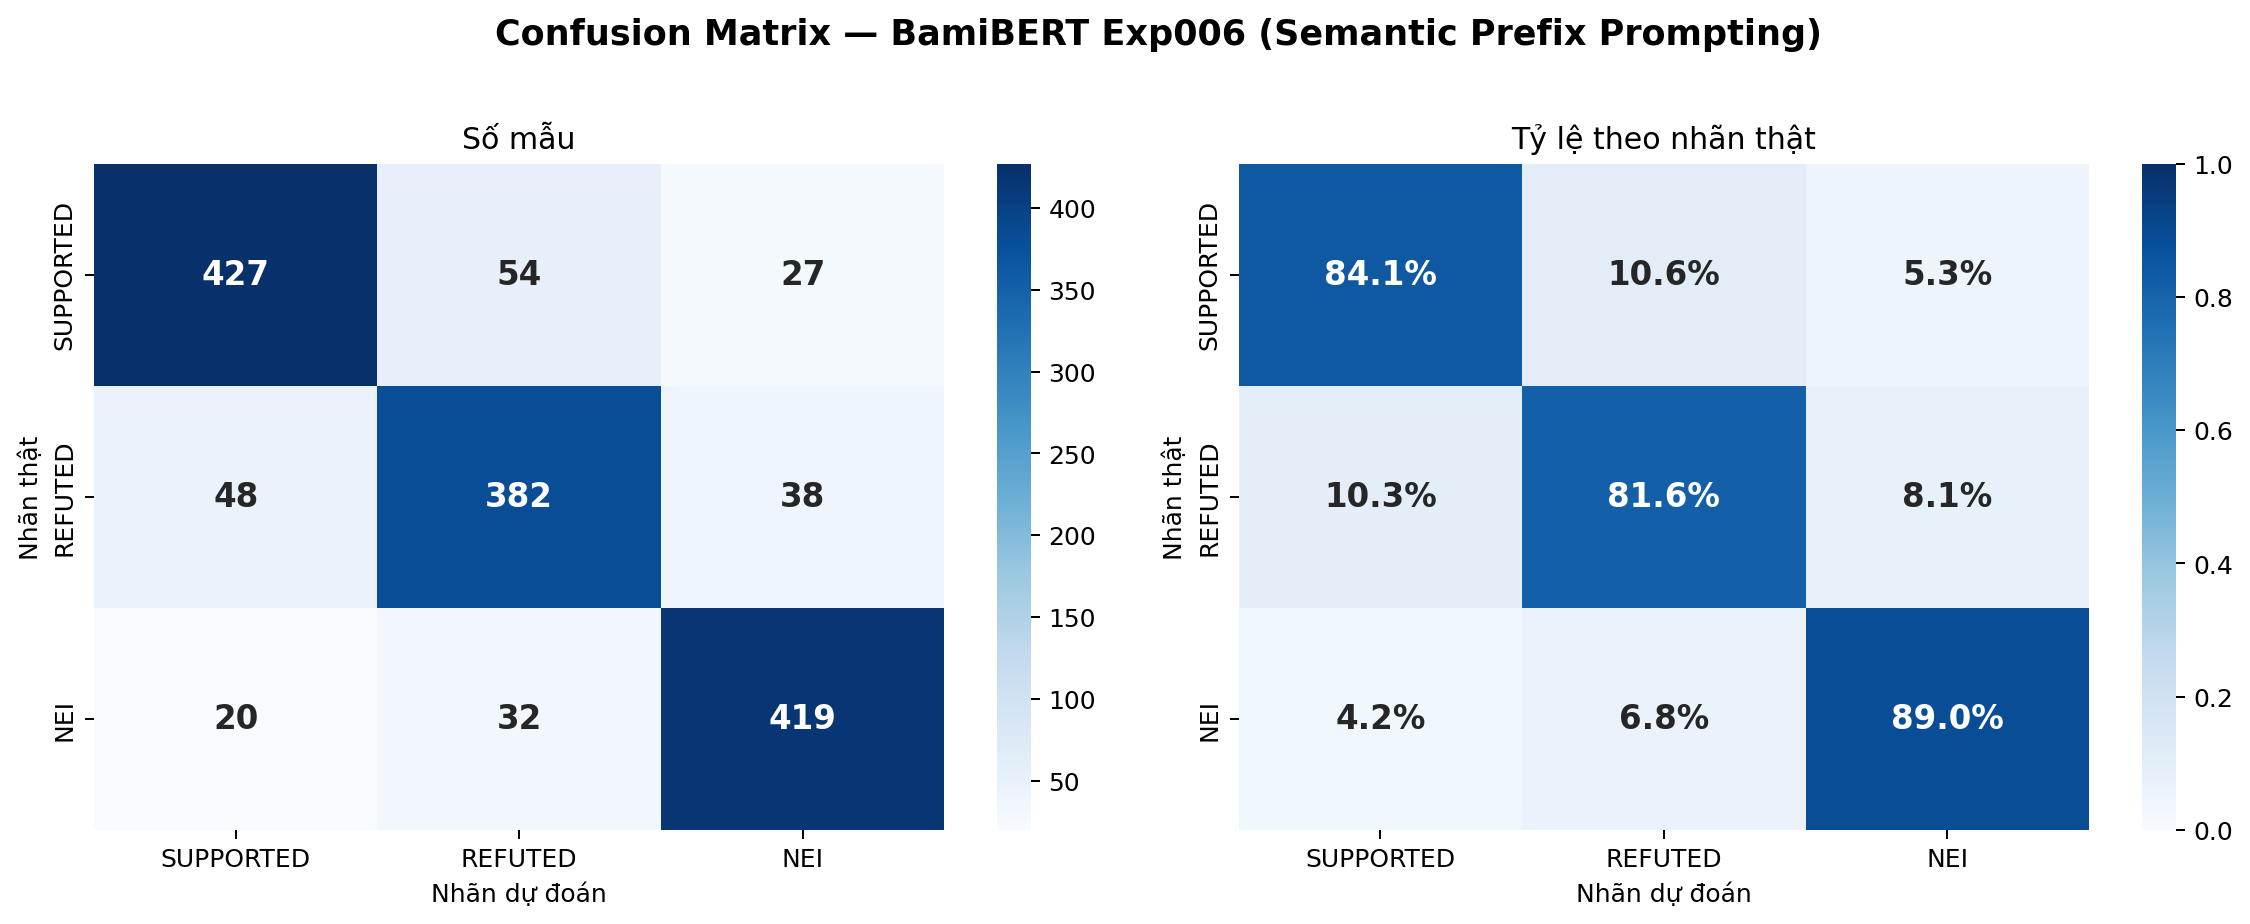

  true_label predicted_label  error_count
0  SUPPORTED         REFUTED           54
1    REFUTED       SUPPORTED           48
2    REFUTED             NEI           38
3        NEI         REFUTED           32
4  SUPPORTED             NEI           27
5        NEI       SUPPORTED           20


💡 [Nhận xét]: Có 219 mẫu sai trên tổng số 1447 mẫu (15.13% lỗi). Hướng nhầm lớn nhất là SUPPORTED → REFUTED: 54 mẫu. Ma trận mô tả hành vi nhầm nhãn; nguyên nhân ngôn ngữ cần đọc từng cặp Statement–Evidence.


In [15]:
# ==============================================================================
# Đánh giá Chi tiết Ma trận nhầm lẫn & Phân tích lỗi (Exp006 - Best Model)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

LABEL_ORDER = ["SUPPORTED", "REFUTED", "NEI"]
EXP006_DIR = Path("./outputs/bamibert/experiments/Exp006_PrefixPrompt_SOTA")
EXP006_DIR.mkdir(parents=True, exist_ok=True)

# 1. Tính toán Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred, labels=LABEL_ORDER)
assert cm.sum() == len(y_test)
cm_df = pd.DataFrame(cm, index=LABEL_ORDER, columns=LABEL_ORDER)
cm_df.to_csv(EXP006_DIR / "09_confusion_matrix_test.csv", index=True)

# 2. Vẽ Heatmap kép: Số lượng mẫu & Tỷ lệ theo nhãn thật (%)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=axes[0], annot_kws={"size": 13, "weight": "bold"})
sns.heatmap(cm_df.div(cm_df.sum(axis=1), axis=0), annot=True, fmt=".1%", cmap="Blues", vmin=0, vmax=1, ax=axes[1], annot_kws={"size": 13, "weight": "bold"})

for ax, title in zip(axes, ["Số mẫu", "Tỷ lệ theo nhãn thật"]):
    ax.set(title=title, xlabel="Nhãn dự đoán", ylabel="Nhãn thật")

fig.suptitle("Confusion Matrix — BamiBERT Exp006 (Semantic Prefix Prompting)", fontsize=14, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig(EXP006_DIR / "09_confusion_matrix_test.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

# 3. Phân tích các ca dự đoán sai (Error Cases) & Cặp nhầm lẫn (Confusion Pairs)
test_predictions = test_df[["index", "Statement", "Evidence", "labels"]].copy()
test_predictions.rename(columns={"index": "source_row", "labels": "true_label_id"}, inplace=True)
test_predictions["true_label"] = y_test
test_predictions["predicted_label"] = y_test_pred
test_predictions["is_correct"] = test_predictions["true_label"].eq(test_predictions["predicted_label"])

error_cases = test_predictions.loc[~test_predictions["is_correct"]].copy()
test_predictions.to_csv(EXP006_DIR / "10_test_predictions.csv", index=False)
error_cases.to_csv(EXP006_DIR / "11_error_cases.csv", index=False)

confusion_pairs = (
    error_cases.groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="error_count")
    .sort_values("error_count", ascending=False)
)
confusion_pairs.to_csv(EXP006_DIR / "12_confusion_pairs.csv", index=False)
display(confusion_pairs)

assert confusion_pairs["error_count"].sum() == len(error_cases)
if not confusion_pairs.empty:
    largest = confusion_pairs.iloc[0]
    print(
        f"\n💡 [Nhận xét]: Có {len(error_cases)} mẫu sai trên tổng số {len(y_test)} mẫu ({len(error_cases)/len(y_test)*100:.2f}% lỗi). "
        f"Hướng nhầm lớn nhất là {largest['true_label']} → {largest['predicted_label']}: {largest['error_count']} mẫu. "
        "Ma trận mô tả hành vi nhầm nhãn; nguyên nhân ngôn ngữ cần đọc từng cặp Statement–Evidence."
    )
else:
    print("Không có mẫu sai trong lần chạy này.")


---
## Thực nghiệm 7 (Exp007): Mở rộng Epochs lên 10 kèm Early Stopping (Patience = 3)
* **Mục tiêu:**
  - Ở baseline 5 epochs, điểm F1 ở epoch 5 vẫn đang trên đà tăng (0.787). Việc mở rộng lên 10 epochs giúp kiểm tra xem mô hình có thể tiếp tục hội tụ tới điểm cực tiểu sâu hơn hay không.
  - **Cơ chế an toàn (Early Stopping):** Cài đặt `early_stopping_patience = 3`. Nếu sau 3 epochs liên tiếp điểm Dev F1 không cải thiện, hệ thống sẽ **tự động ngắt huấn luyện** để tiết kiệm thời gian và ngăn chặn hiện tượng quá khớp (overfitting).
  - Nhờ `load_best_model_at_end = True`, checkpoint cuối cùng được lưu lại luôn là model ở epoch đạt điểm Dev F1 cao nhất (ví dụ nếu epoch 6 tốt nhất thì dù dừng ở epoch 9, model vẫn lấy trọng số của epoch 6).
* **Cấu hình:** `num_train_epochs = 10, early_stopping_patience = 3, lr = 2e-5, effective_bs = 16, warmup = 0.1`.

In [17]:
# Thực thi Thực nghiệm: Tăng số Epochs lên 10 kèm Early Stopping
res_exp_epochs10, lb = run_experiment(
    exp_id="Exp007_Epochs10_EarlyStop",
    description="Mở rộng lên 10 Epochs kèm Early Stopping (Patience = 3, Warmup 10%, Eff BS = 16)",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=10,             # Tăng lên tối đa 10 epochs
    early_stopping_patience=3,        # Dừng sớm nếu 3 epochs liên tiếp không tăng Dev F1
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="linear",
    class_weights=None,              # Giữ loss chuẩn để so sánh công bằng tác động của epoch
    use_prefix_prompt=False
)

🚀 BẮT ĐẦU THỰC NGHIỆM: Exp007_Epochs10_EarlyStop
Mô tả: Mở rộng lên 10 Epochs kèm Early Stopping (Patience = 3, Warmup 10%, Eff BS = 16)
Cấu hình: LR=2e-05 | Batch=8x2 (Eff=16)
Epochs=10 | Warmup=0.1 | Decay=0.01 | Scheduler=linear
Class Weights=None | Prefix Prompt=False


Map: 100%|██████████████| 1447/1447 [00:00<00:00, 24940.55 examples/s]
/opt/anaconda3/envs/bamibert/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 61334672-8e7f-4450-84a1-6f645395147f)')' thrown while requesting HEAD https://huggingface.co/Qualcomm-AI-Research/BamiBERT/resolve/main/config.json
Retrying in 1s [Retry 1/5].
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Qualcomm-AI-Research/BamiBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to 

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
0,0.862600,0.746539,0.688797,0.688449
2,0.418100,0.568040,0.804979,0.803936
4,0.175100,0.944479,0.782849,0.783617
6,0.055300,1.095379,0.814661,0.814793
8,0.058700,1.204585,0.811895,0.812581
9,0.034000,1.224894,0.809129,0.809701



--- KẾT QUẢ TRÊN TẬP DEV ---
Dev Loss: 1.0954 | Accuracy: 81.47% | Macro F1: 0.8148

--- KẾT QUẢ TRÊN TẬP TEST ---
Test Loss: 0.9921 | Accuracy: 82.38% | Macro F1: 0.8210

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
• SUPPORTED   : Precision=0.8301 | Recall=0.8465 | F1=0.8382
• REFUTED     : Precision=0.8505 | Recall=0.7051 | F1=0.7710
• NEI         : Precision=0.7985 | Recall=0.9172 | F1=0.8538

✓ Đã cập nhật kết quả vào Leaderboard tại: outputs/bamibert/experiments_leaderboard.csv


---
## 10. Tổng kết Chuỗi Thực nghiệm & Biểu đồ So sánh (Final Ablation Charts)
Khối mã dưới đây đọc toàn bộ lịch sử từ file `experiments_leaderboard.csv` và vẽ biểu đồ cột so sánh:
1. **Macro-F1 Tổng thể** qua từng thử nghiệm.
2. **F1 riêng của lớp `REFUTED`** để xem lớp khó nhất này đã được cải thiện như thế nào.

/var/folders/q3/gz04hwfj2rn8hq_gtqq5vf_m0000gn/T/ipykernel_2665/1479064489.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar1 = sns.barplot(


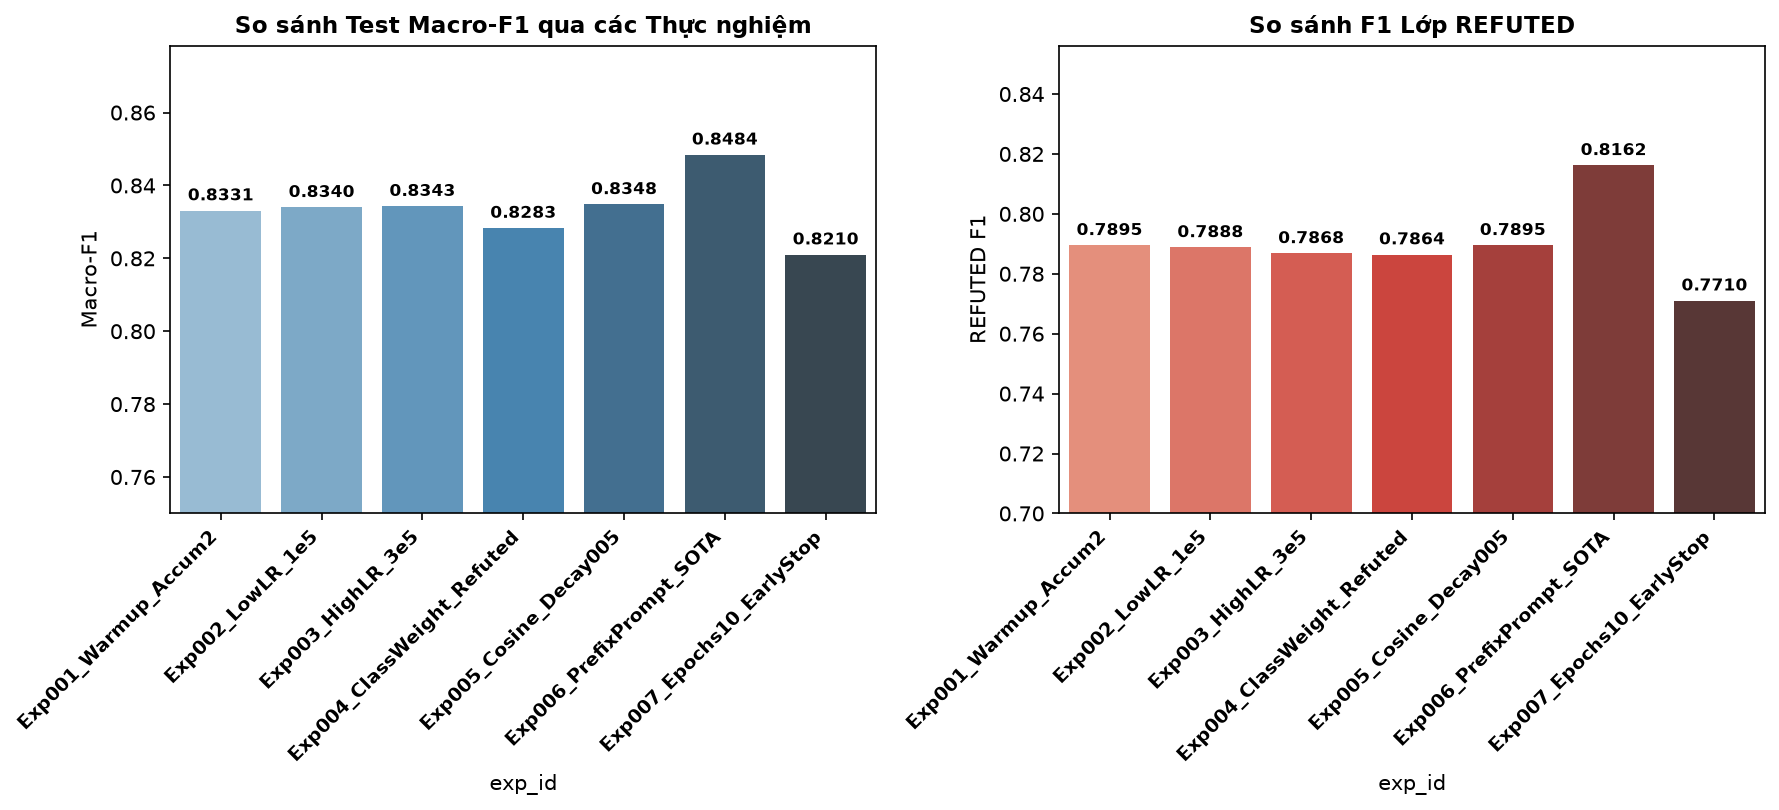

🏆 MÔ HÌNH XUẤT SẮC NHẤT (FINAL SOTA): Exp006_PrefixPrompt_SOTA
• Test Macro-F1: 0.8484 (so với Baseline: 0.8157 | Tăng: +3.27%)
• REFUTED F1:    0.8162 (so với Baseline: 0.7500 | Tăng: +6.62%)
• Checkpoint:    ./outputs/bamibert/experiments/Exp006_PrefixPrompt_SOTA/best_model


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

if LEADERBOARD_FILE.exists():
    df_lb = pd.read_csv(LEADERBOARD_FILE)
    
    plt.figure(figsize=(12, 5.5), dpi=150)
    
    # 1. Biểu đồ Macro F1
    plt.subplot(1, 2, 1)
    bar1 = sns.barplot(
        data=df_lb,
        x="exp_id",
        y="test_f1_macro",
        palette="Blues_d"
    )
    plt.xticks(rotation=45, ha="right", fontsize=9, fontweight="bold")
    plt.title("So sánh Test Macro-F1 qua các Thực nghiệm", fontsize=11, fontweight="bold")
    plt.ylabel("Macro-F1", fontsize=10)
    plt.ylim(0.75, max(df_lb["test_f1_macro"].max() + 0.03, 0.86))
    for p in bar1.patches:
        bar1.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=8, xytext=(0, 3), textcoords='offset points', fontweight="bold")

    # 2. Biểu đồ REFUTED F1
    plt.subplot(1, 2, 2)
    bar2 = sns.barplot(
        data=df_lb,
        x="exp_id",
        y="refuted_f1",
        hue="exp_id",       
        palette="Reds_d",
        legend=False     
    )
    plt.xticks(rotation=45, ha="right", fontsize=9, fontweight="bold")
    plt.title("So sánh F1 Lớp REFUTED", fontsize=11, fontweight="bold")
    plt.ylabel("REFUTED F1", fontsize=10)
    plt.ylim(0.70, max(df_lb["refuted_f1"].max() + 0.04, 0.85))
    for p in bar2.patches:
        bar2.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=8, xytext=(0, 3), textcoords='offset points', fontweight="bold")

    plt.tight_layout()
    plt.show()

    # Tìm model tốt nhất
    best_row = df_lb.loc[df_lb["test_f1_macro"].idxmax()]
    
    # Lấy giá trị baseline an toàn (mặc định lấy 0.8157 và 0.7500 nếu chưa có dòng Exp000)
    has_baseline = (df_lb['exp_id'] == 'Exp000_Baseline').any()
    base_f1 = df_lb.loc[df_lb['exp_id'] == 'Exp000_Baseline', 'test_f1_macro'].values[0] if has_baseline else 0.8157
    base_refuted = df_lb.loc[df_lb['exp_id'] == 'Exp000_Baseline', 'refuted_f1'].values[0] if has_baseline else 0.7500
    print("=" * 80)
    print(f"🏆 MÔ HÌNH XUẤT SẮC NHẤT (FINAL SOTA): {best_row['exp_id']}")
    print(f"• Test Macro-F1: {best_row['test_f1_macro']:.4f} (so với Baseline: {base_f1:.4f} | Tăng: +{(best_row['test_f1_macro'] - base_f1)*100:.2f}%)")
    print(f"• REFUTED F1:    {best_row['refuted_f1']:.4f} (so với Baseline: {base_refuted:.4f} | Tăng: +{(best_row['refuted_f1'] - base_refuted)*100:.2f}%)")
    print(f"• Checkpoint:    {best_row['checkpoint_dir']}")
    print("=" * 80)